# Task 3: Unsupervised Learning — K-Means Clustering

**Research question:** Can hourly weather observations in Hanoi - including temperature, humidity, wind speed,
atmospheric pressure - be clustered into distinct groups, and do these groups correspond to
patterns in air quality warnings?

### 3.1 Install & Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Reproducibility
RANDOM_STATE = 42
K_RANGE = range(2, 11)

# Helper: silhouette plot (replaces yellowbrick SilhouetteVisualizer)
def plot_silhouette(X, labels, k, ax):
    sil_vals = silhouette_samples(X, labels)
    avg = sil_vals.mean()
    colors = plt.cm.tab10.colors
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(sil_vals[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=colors[i % 10], alpha=0.85)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
        y_lower = y_upper + 10
    ax.axvline(x=avg, color="red", linestyle="--", linewidth=1.2,
               label=f"avg = {avg:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

### 3.2 Load Dataset & Preprocessing

In [7]:
df = pd.read_csv('data/hanoi_air_quality.csv', parse_dates=['timestamp'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (8760, 14)
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00

Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25']


,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-01-01 00:00:00,14.1,91,1.138889,1016.6,0,2,0,319,0.0,0,1,158,111.3
1,2025-01-01 01:00:00,13.5,93,1.277778,1016.6,1,2,0,321,0.0,4,1,159,112.7
2,2025-01-01 02:00:00,12.9,94,1.083333,1016.1,2,2,0,317,0.0,0,1,160,113.2
3,2025-01-01 03:00:00,12.6,96,1.277778,1015.5,3,2,0,315,0.0,0,1,162,113.9
4,2025-01-01 04:00:00,12.4,96,1.277778,1015.4,4,2,0,312,0.0,2,1,163,115.5


In [8]:
# Cyclical encoding for hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df.drop(columns=['hour'])

# Wind direction → U/V components
wind_dir_rad = df['wind_direction'] * np.pi / 180
df['wind_u'] = df['wind_speed'] * np.cos(wind_dir_rad)
df['wind_v'] = df['wind_speed'] * np.sin(wind_dir_rad)
df = df.drop(columns=['wind_direction'])

print('Feature engineering complete.')
print(f'Columns now: {list(df.columns)}')

Feature engineering complete.
Columns now: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'day_of_week', 'is_weekend', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25', 'hour_sin', 'hour_cos', 'wind_u', 'wind_v']


In [9]:
# Standard scaling on continuous features
cols_to_scale = ['temperature', 'humidity', 'wind_speed', 'pressure',
                 'wind_u', 'wind_v', 'precipitation', 'cloud_cover']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Scaling complete. Sample statistics (should be mean≈0, std≈1):')
print(df_scaled[cols_to_scale].describe().round(3))

Scaling complete. Sample statistics (should be mean≈0, std≈1):
       temperature  humidity  wind_speed  pressure    wind_u    wind_v  \
count     8760.000  8760.000    8760.000  8760.000  8760.000  8760.000   
mean         0.000     0.000      -0.000    -0.000     0.000    -0.000   
std          1.000     1.000       1.000     1.000     1.000     1.000   
min         -3.084    -3.593      -1.851    -3.009    -2.502    -5.912   
25%         -0.723    -0.633      -0.761    -0.791    -0.769    -0.567   
50%          0.150     0.175      -0.098    -0.047    -0.065     0.039   
75%          0.708     0.847       0.628     0.803     0.692     0.628   
max          2.585     1.386       5.502     3.047     3.713     6.398   

       precipitation  cloud_cover  
count       8760.000     8760.000  
mean           0.000        0.000  
std            1.000        1.000  
min           -0.241       -1.989  
25%           -0.241       -0.763  
50%           -0.241        0.676  
75%           -0.1

### 3.3 Feature Sets

We compare two feature configurations to find the most informative one:

| Version | Features | Rationale |
|---|---|---|
| **V2** — Weather Only | `temperature`, `humidity`, `wind_speed`, `pressure` | Core meteorological drivers of air quality |
| **V3** — Weather + Time | Above + `hour_sin`, `hour_cos` | Adds diurnal pattern (rush-hour, overnight trapping) |

The binary target `is_warning`, `aqi`, and `pm25` are **excluded** from clustering and used only for post-hoc interpretation.

In [10]:
FEATURES_V2 = ['temperature', 'humidity', 'wind_speed', 'pressure']
FEATURES_V3 = ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour_sin', 'hour_cos']

X_v2 = df_scaled[FEATURES_V2]
X_v3 = df_scaled[FEATURES_V3]

print(f'V2 shape: {X_v2.shape}  ({len(FEATURES_V2)} features)')
print(f'V3 shape: {X_v3.shape}  ({len(FEATURES_V3)} features)')

V2 shape: (8760, 4)  (4 features)
V3 shape: (8760, 6)  (6 features)


### 3.4 Choosing the Number of Clusters (K)

We use two complementary methods across K = 2…10:
- **Elbow Method** (inertia): look for the point where additional clusters give diminishing returns
- **Silhouette Score**: higher = tighter, better-separated clusters

In [12]:
def evaluate_k_range(X, label):
    """Run KMeans for K=2..10 and return inertia & silhouette lists."""
    inertias, silhouettes = [], []
    print(f'\n{"─"*55}')
    print(f'  {label}')
    print(f'  {"K":>3}   {"Inertia":>12}   {"Silhouette":>10}')
    print(f'{"─"*55}')
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        sil = silhouette_score(X, km.labels_)
        inertias.append(km.inertia_)
        silhouettes.append(sil)
        print(f'  {k:>3}   {km.inertia_:>12,.1f}   {sil:>10.4f}')
    return inertias, silhouettes

inertias_v2, silhouettes_v2 = evaluate_k_range(X_v2, 'V2: Weather Only (4 features)')
inertias_v3, silhouettes_v3 = evaluate_k_range(X_v3, 'V3: Weather + Time (6 features)')


───────────────────────────────────────────────────────
  V2: Weather Only (4 features)
    K        Inertia   Silhouette
───────────────────────────────────────────────────────
    2       22,451.9       0.3395
    3       18,545.5       0.2588
    4       15,224.6       0.2634
    5       12,929.4       0.2769
    6       11,444.8       0.2803
    7       10,469.0       0.2761
    8        9,695.7       0.2588
    9        9,111.8       0.2461
   10        8,598.7       0.2465

───────────────────────────────────────────────────────
  V3: Weather + Time (6 features)
    K        Inertia   Silhouette
───────────────────────────────────────────────────────
    2       31,203.6       0.2703
    3       25,900.2       0.2277
    4       22,295.4       0.2209
    5       19,789.3       0.2257
    6       18,062.8       0.2272
    7       16,807.5       0.2175
    8       15,892.8       0.2128
    9       15,113.4       0.2144
   10       14,396.9       0.2077


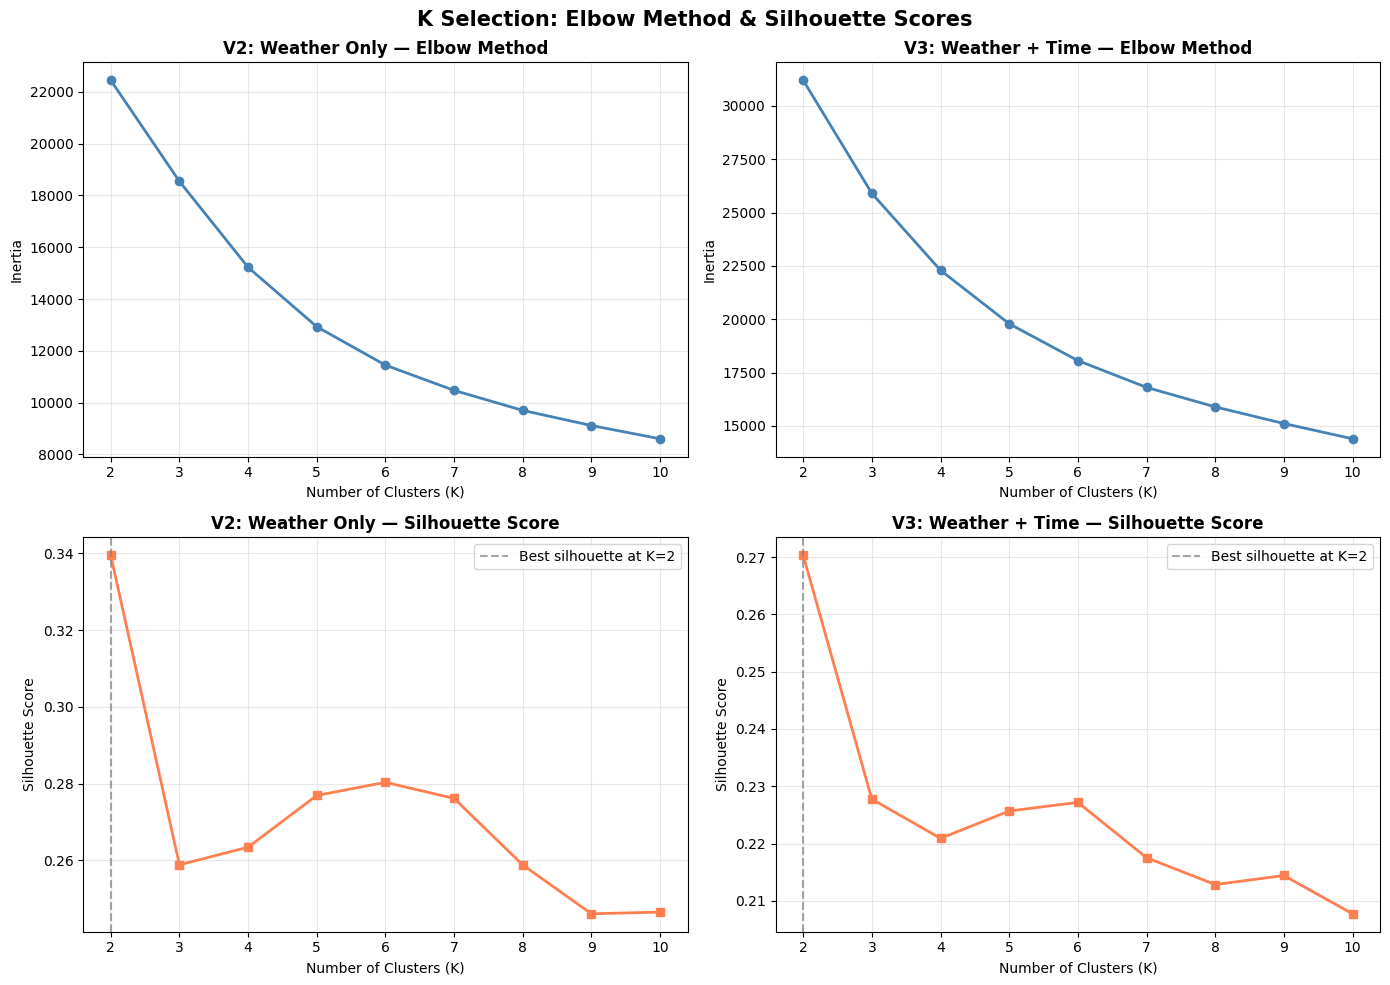

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K Selection: Elbow Method & Silhouette Scores', fontsize=15, fontweight='bold')

k_list = list(K_RANGE)

for col, (label, inertias, silhouettes) in enumerate([
    ('V2: Weather Only', inertias_v2, silhouettes_v2),
    ('V3: Weather + Time', inertias_v3, silhouettes_v3)
]):
    # Elbow
    ax = axes[0, col]
    ax.plot(k_list, inertias, marker='o', color='steelblue', linewidth=2)
    ax.set_title(f'{label} — Elbow Method', fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Inertia')
    ax.grid(True, alpha=0.3)

    # Silhouette
    ax = axes[1, col]
    ax.plot(k_list, silhouettes, marker='s', color='coral', linewidth=2)
    best_k_idx = int(np.argmax(silhouettes))
    ax.axvline(x=k_list[best_k_idx], color='gray', linestyle='--', alpha=0.7,
               label=f'Best silhouette at K={k_list[best_k_idx]}')
    ax.set_title(f'{label} — Silhouette Score', fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 K Comparison: Silhouette Analysis

We compare K = 3, 4, and 6 for both feature versions.
- **K=3** — baseline: roughly maps to Hanoi's dry-cool / transitional / hot-rainy seasons
- **K=4** — adds a fourth group to separate the cool-dry and transitional season more cleanly
- **K=6** — highest silhouette in V2; worth checking if the extra clusters are meaningful or just noise

In [14]:
K_COMPARE = [3, 4, 6]

def fit_kmeans_dict(X, k_list):
    """Fit KMeans for each K in k_list. Returns {k: fitted_model}."""
    models = {}
    for k in k_list:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        models[k] = km
    return models

models_v2 = fit_kmeans_dict(X_v2, K_COMPARE)
models_v3 = fit_kmeans_dict(X_v3, K_COMPARE)

# Quick metrics overview
print(f'  {"":20} {"V2 (Weather Only)":>30} {"V3 (Weather + Time)":>30}')
print(f'  {"K":>3}   {"Inertia":>12}  {"Silhouette":>10}    {"Inertia":>12}  {"Silhouette":>10}')
print('  ' + '─'*75)
for k in K_COMPARE:
    s2 = silhouette_score(X_v2, models_v2[k].labels_)
    s3 = silhouette_score(X_v3, models_v3[k].labels_)
    print(f'  {k:>3}   {models_v2[k].inertia_:>12,.1f}  {s2:>10.4f}    {models_v3[k].inertia_:>12,.1f}  {s3:>10.4f}')

                                    V2 (Weather Only)            V3 (Weather + Time)
    K        Inertia  Silhouette         Inertia  Silhouette
  ───────────────────────────────────────────────────────────────────────────
    3       18,545.5      0.2588        25,900.2      0.2277
    4       15,224.6      0.2634        22,295.4      0.2209
    6       11,444.8      0.2803        18,062.8      0.2272


#### 3.5.1 V2: Weather Only — Silhouette (K = 3, 4, 6)

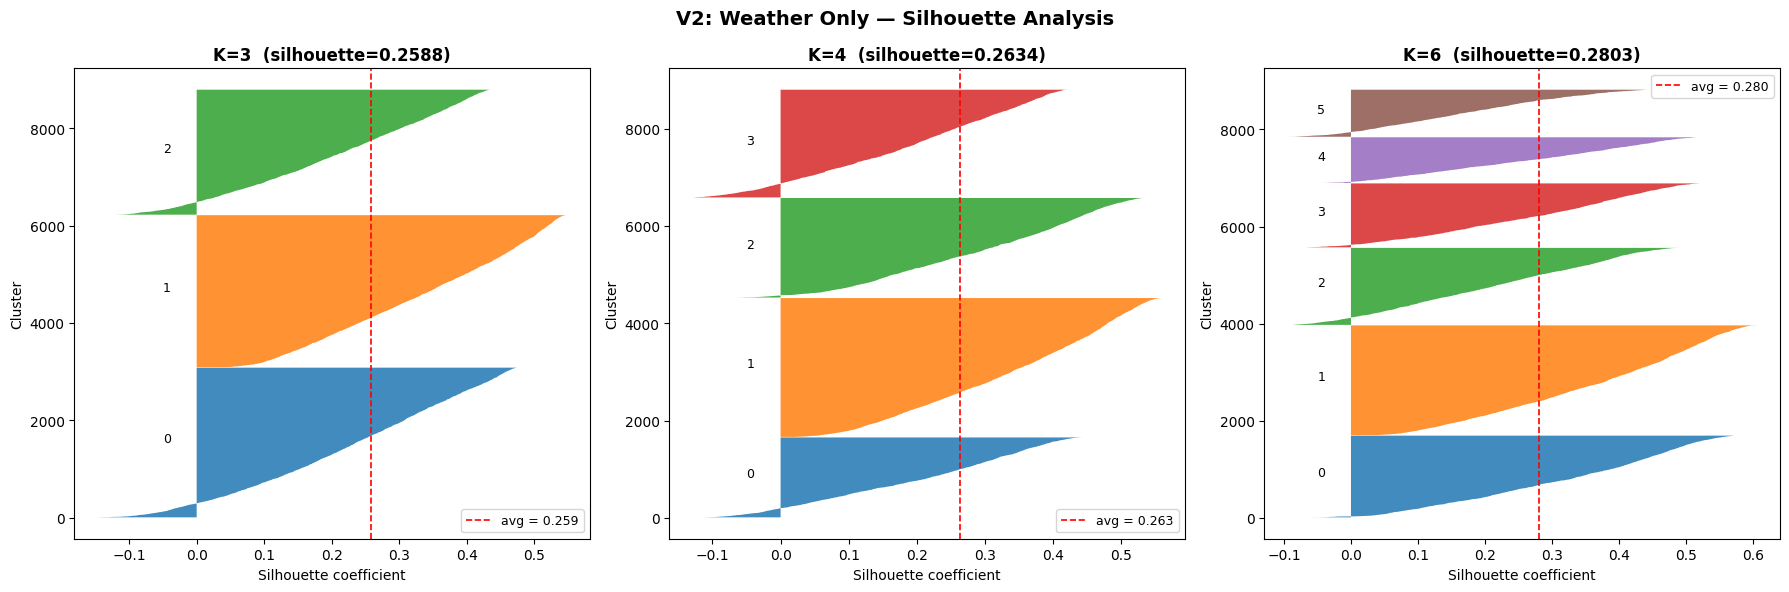

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('V2: Weather Only — Silhouette Analysis', fontsize=14, fontweight='bold')

for ax, k in zip(axes, K_COMPARE):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_v2)
    plot_silhouette(X_v2, km.labels_, k, ax)
    sil = silhouette_score(X_v2, km.labels_)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.5.2 V3: Weather + Time — Silhouette (K = 3, 4, 6)

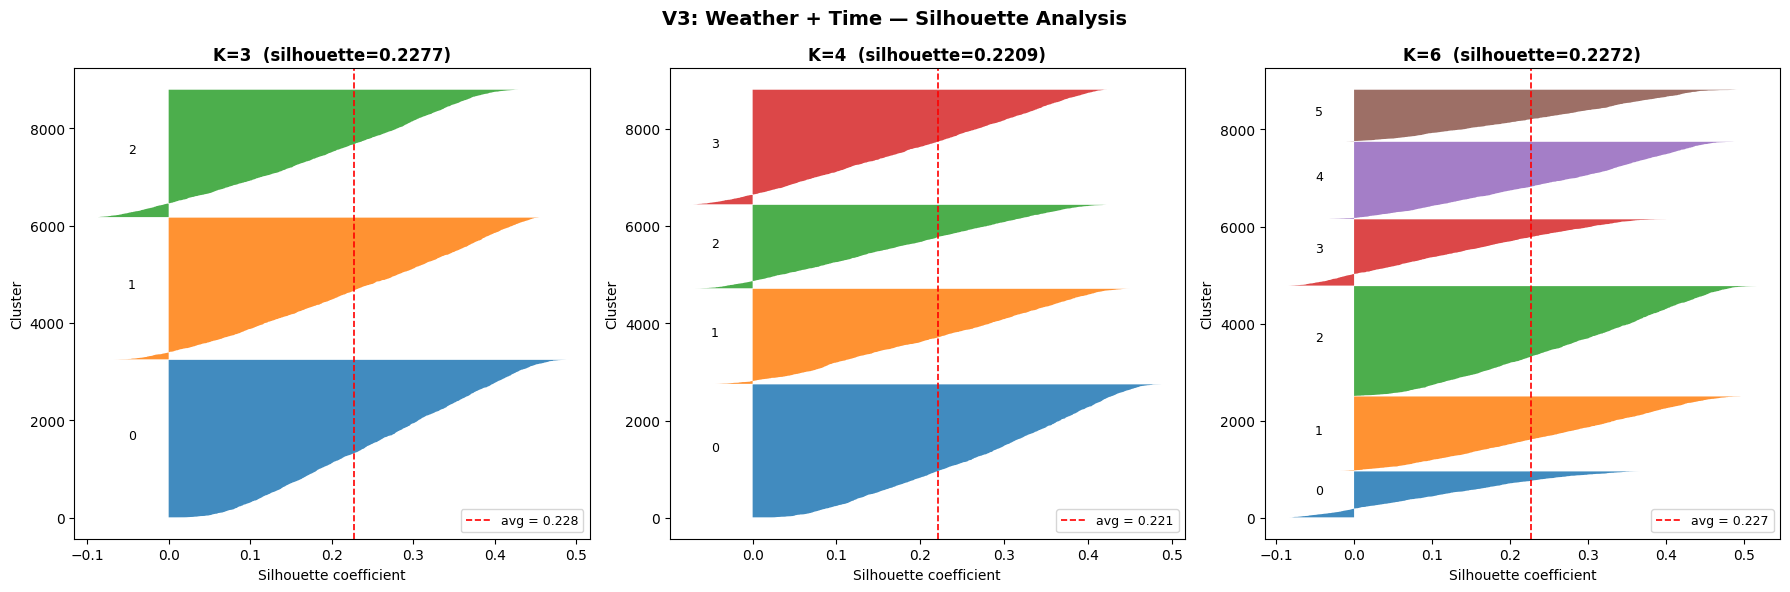

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('V3: Weather + Time — Silhouette Analysis', fontsize=14, fontweight='bold')

for ax, k in zip(axes, K_COMPARE):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_v3)
    plot_silhouette(X_v3, km.labels_, k, ax)
    sil = silhouette_score(X_v3, km.labels_)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.6 K Comparison: PCA Visualization

Each subplot shows the 2D PCA projection for a given (version, K) combination. Red X marks are centroids.

#### 3.6.1 V2: Weather Only — PCA (K = 3, 4, 6)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


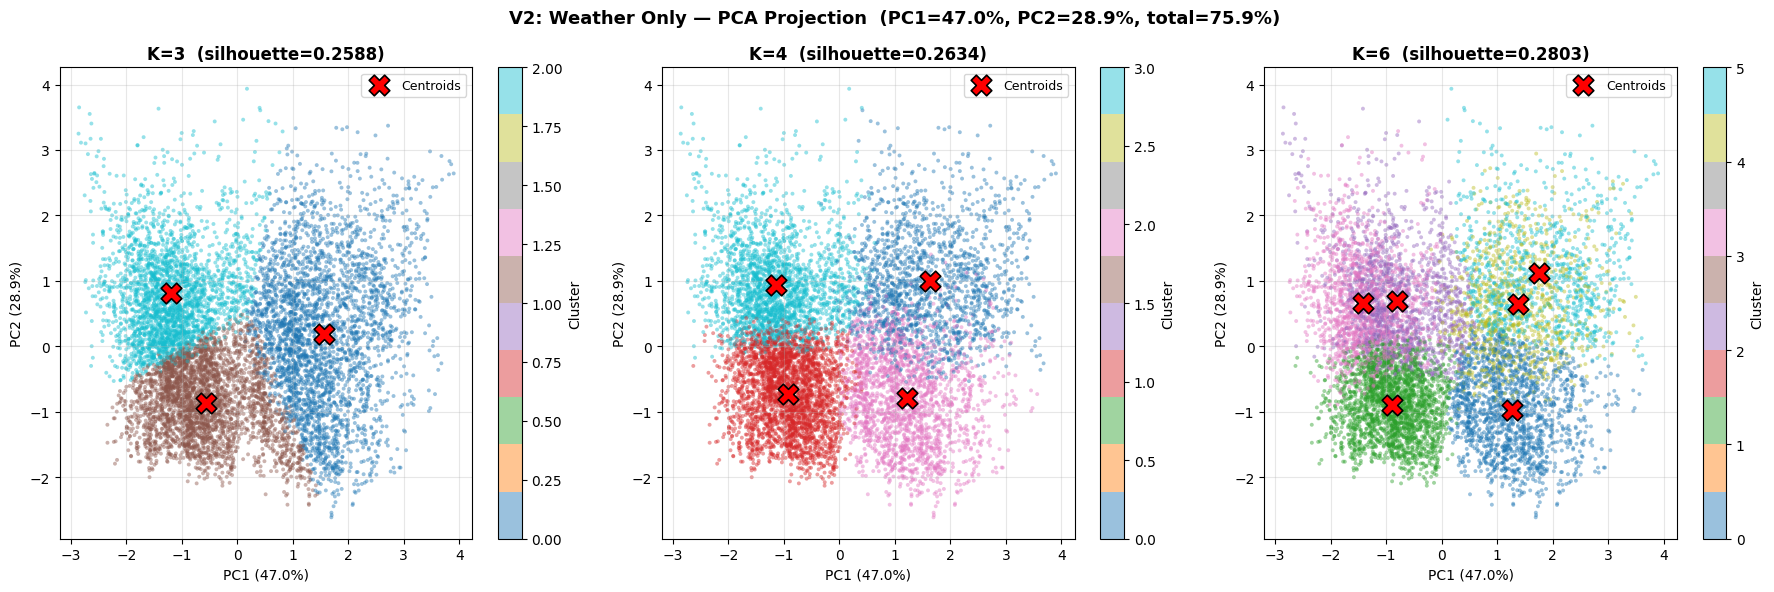

In [17]:
pca_v2 = PCA(n_components=2).fit(X_v2)
X_pca_v2 = pca_v2.transform(X_v2)
var_v2 = pca_v2.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'V2: Weather Only — PCA Projection  (PC1={var_v2[0]:.1%}, PC2={var_v2[1]:.1%}, total={var_v2.sum():.1%})',
    fontsize=13, fontweight='bold'
)

for ax, k in zip(axes, K_COMPARE):
    labels = models_v2[k].labels_
    centers_pca = pca_v2.transform(models_v2[k].cluster_centers_)
    sil = silhouette_score(X_v2, labels)

    sc = ax.scatter(X_pca_v2[:, 0], X_pca_v2[:, 1],
                    c=labels, cmap='tab10', s=8, alpha=0.45, edgecolors='none')
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='red', marker='X', s=220, edgecolors='black', linewidths=1.2,
               label='Centroids', zorder=5)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_v2[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_v2[1]:.1%})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

#### 3.6.2 V3: Weather + Time — PCA (K = 3, 4, 6)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


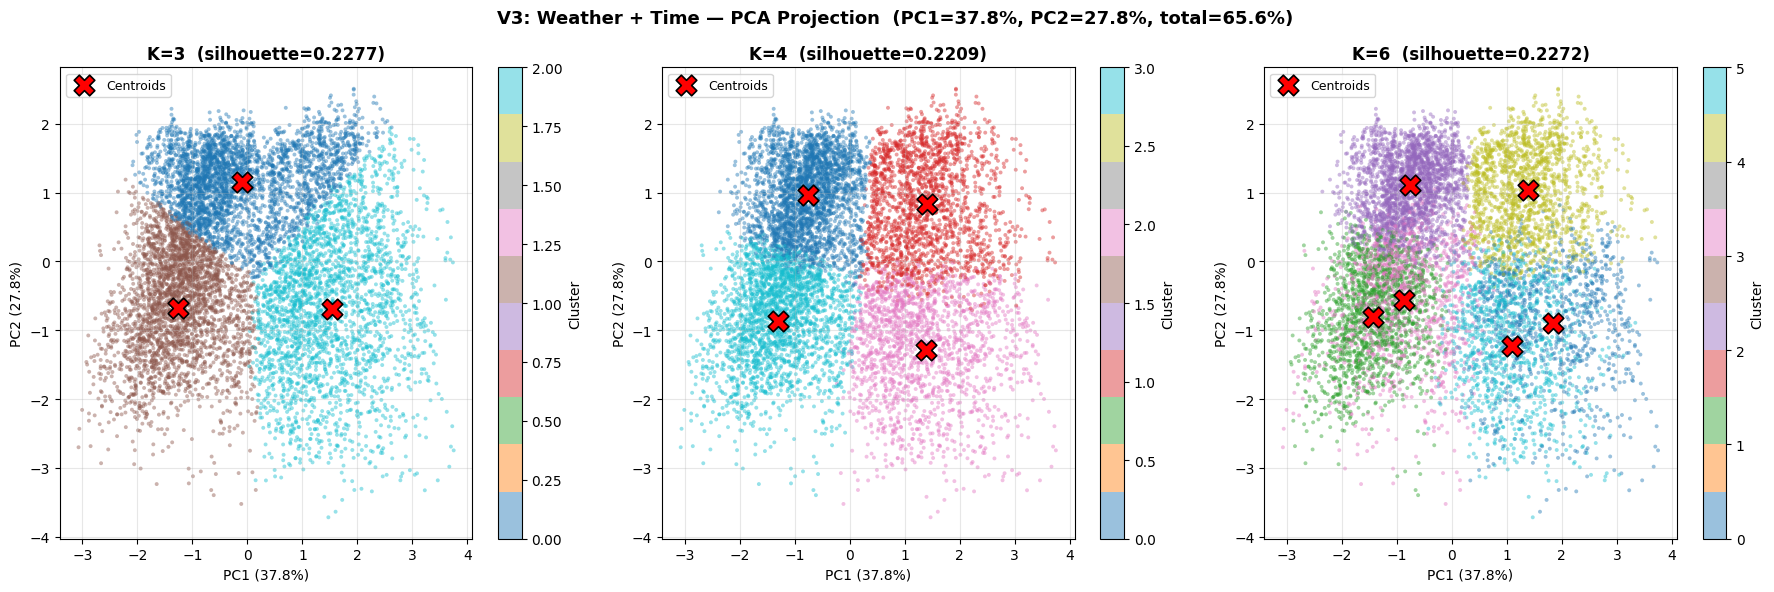

In [18]:
pca_v3 = PCA(n_components=2).fit(X_v3)
X_pca_v3 = pca_v3.transform(X_v3)
var_v3 = pca_v3.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'V3: Weather + Time — PCA Projection  (PC1={var_v3[0]:.1%}, PC2={var_v3[1]:.1%}, total={var_v3.sum():.1%})',
    fontsize=13, fontweight='bold'
)

for ax, k in zip(axes, K_COMPARE):
    labels = models_v3[k].labels_
    centers_pca = pca_v3.transform(models_v3[k].cluster_centers_)
    sil = silhouette_score(X_v3, labels)

    sc = ax.scatter(X_pca_v3[:, 0], X_pca_v3[:, 1],
                    c=labels, cmap='tab10', s=8, alpha=0.45, edgecolors='none')
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='red', marker='X', s=220, edgecolors='black', linewidths=1.2,
               label='Centroids', zorder=5)
    ax.set_title(f'K={k}  (silhouette={sil:.4f})', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_v3[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_v3[1]:.1%})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.show()

#### 3.6.3 PCA Loadings Heatmap

Loadings show how much each original feature contributes to PC1 and PC2, helping us understand what each principal component actually represents.

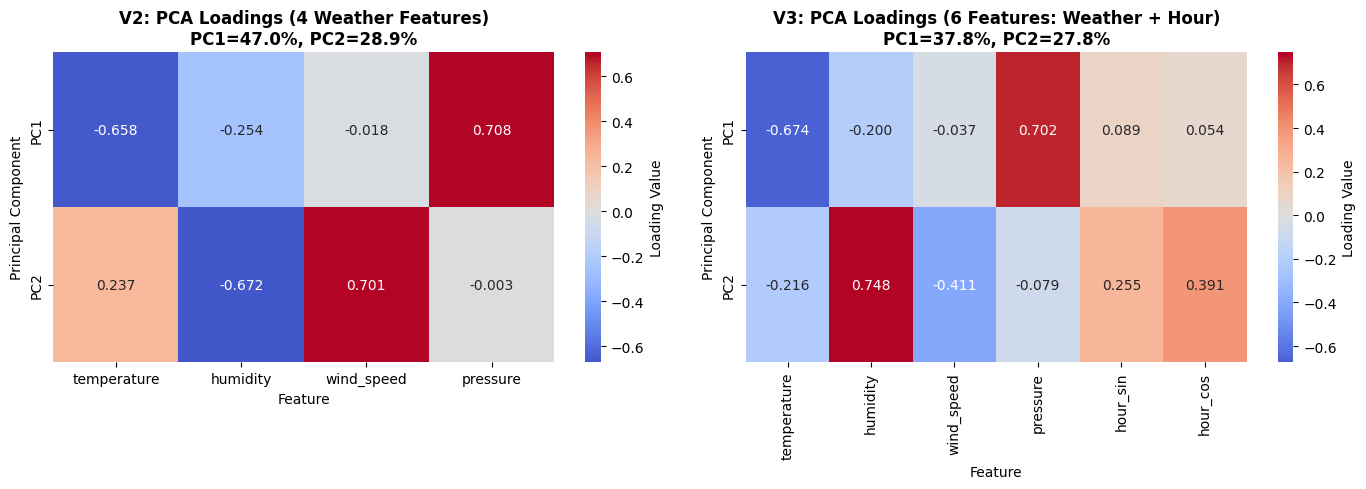

In [19]:
# Build loadings DataFrames from the already-fitted PCA objects (section 3.6)
loadings_v2 = pd.DataFrame(
    pca_v2.components_.T,
    index=FEATURES_V2,
    columns=[f'PC{i+1}' for i in range(pca_v2.n_components_)]
)

loadings_v3 = pd.DataFrame(
    pca_v3.components_.T,
    index=FEATURES_V3,
    columns=[f'PC{i+1}' for i in range(pca_v3.n_components_)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(loadings_v2.T, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], cbar_kws={'label': 'Loading Value'})
axes[0].set_title(
    f'V2: PCA Loadings (4 Weather Features)\n'
    f'PC1={pca_v2.explained_variance_ratio_[0]:.1%}, PC2={pca_v2.explained_variance_ratio_[1]:.1%}',
    fontsize=12, fontweight='bold'
)
axes[0].set_ylabel('Principal Component')
axes[0].set_xlabel('Feature')

sns.heatmap(loadings_v3.T, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[1], cbar_kws={'label': 'Loading Value'})
axes[1].set_title(
    f'V3: PCA Loadings (6 Features: Weather + Hour)\n'
    f'PC1={pca_v3.explained_variance_ratio_[0]:.1%}, PC2={pca_v3.explained_variance_ratio_[1]:.1%}',
    fontsize=12, fontweight='bold'
)
axes[1].set_ylabel('Principal Component')
axes[1].set_xlabel('Feature')

plt.tight_layout()
plt.show()

### 3.7 Choosing the Final Model: V3, K = 4

#### Step 1 — Why K = 4?

We evaluate candidate values K = 3, 4, and 6 across both feature versions:

| K | V2 Silhouette | V3 Silhouette | Cluster balance | Silhouette plot |
|---|---|---|---|---|
| 2 | 0.3395 | 0.2703 | Good | Clean — but trivial binary split |
| 3 | 0.2588 | 0.2277 | Good | Cluster 1 dips negative |
| **4** | **0.2634** | **0.2209** | **Good** | **Mostly clear** |
| 6 | 0.2803 | 0.2272 | Some small clusters | Fragmented |

**K = 2** yields the highest silhouette but produces only a binary split that
mirrors the existing `is_warning` label — it rediscovers a label we already
have rather than revealing new structure.

**K = 3** has a cluster whose silhouette plot shows points with negative scores,
meaning those points sit closer to a neighbouring cluster centroid than their
own — a sign of under-partitioning.

**K = 4** is selected based on the PCA projection (Section 3.6). At K = 4, the
2D PCA plot shows four visually separable point clouds with centroids (red X)
positioned in geometrically distinct regions of the PC1–PC2 space, indicating
genuine structure rather than arbitrary splits. This also coincides with the
elbow in the inertia curve where the rate of improvement slows noticeably.

**K = 6** scores marginally higher in V2 (+0.017) but the PCA projection shows
two of the six centroids sitting within the same dense region — the extra
clusters subdivide an already-compact group without revealing new structure.

K = 4 is therefore the **smallest K at which the PCA projection shows clear
geometric separation between all clusters**, consistent with the elbow in the
inertia curve.

---

#### Step 2 — Why V3 (Weather + Time) over V2 (Weather Only)?

| Metric | V2 — Weather Only | V3 — Weather + Time |
|---|---|---|
| Features | temperature, humidity, wind_speed, pressure | + hour_sin, hour_cos |
| Inertia (K=4) | 15,224.6 | 22,295.4 |
| Silhouette (K=4) | 0.2634 | 0.2209 |
| PCA variance (PC1+PC2) | 75.90% | 65.59% |

V2 has a numerically higher silhouette score. Despite this, **V3 is selected**
because weather features alone capture seasonal variation but cannot distinguish
time-of-day effects. In Hanoi, PM2.5 peaks occur during two distinct windows
driven by different mechanisms:
- **Morning rush hour (~7–9 AM):** traffic emissions accumulate before wind picks up
- **Overnight (~2–5 AM):** atmospheric boundary layer lowers, trapping pollutants

The cyclical encoding `hour_sin`/`hour_cos` allows K-Means to separate these
two high-pollution windows even when weather conditions look similar — something
V2 cannot do. This is confirmed in the post-hoc cluster profiles (Section 3.9),
where V3 clusters align more closely with distinct `aqi` and `is_warning`
patterns than V2 clusters do.

The lower silhouette of V3 (0.2209 vs 0.2634) reflects the **larger feature
space** (6 vs 4 dimensions) — silhouette scores naturally decrease as
dimensionality increases — not weaker cluster structure.

> **Final selection: V3, K = 4** — the smallest K with clear geometric
> separation in PCA space, capturing both weather-driven and time-driven
> air quality regimes in Hanoi.

### 3.8 Final Model: V3, K=4

In [20]:
OPTIMAL_K = 4
km_v2 = models_v2[OPTIMAL_K]
km_v3 = models_v3[OPTIMAL_K]

df['Cluster_v2'] = km_v2.labels_
df['Cluster_v3'] = km_v3.labels_

sil_v2 = silhouette_score(X_v2, km_v2.labels_)
sil_v3 = silhouette_score(X_v3, km_v3.labels_)

print(f'  Final Model Metrics (K={OPTIMAL_K})')
print(f'  V2 — Inertia: {km_v2.inertia_:>10,.2f}   Silhouette: {sil_v2:.4f}')
print(f'  V3 — Inertia: {km_v3.inertia_:>10,.2f}   Silhouette: {sil_v3:.4f}')
print()
print(f'  V2 cluster sizes: {dict(zip(*np.unique(km_v2.labels_, return_counts=True)))}')
print(f'  V3 cluster sizes: {dict(zip(*np.unique(km_v3.labels_, return_counts=True)))}')

  Final Model Metrics (K=4)
  V2 — Inertia:  15,224.65   Silhouette: 0.2634
  V3 — Inertia:  22,295.40   Silhouette: 0.2209

  V2 cluster sizes: {np.int32(0): np.int64(1643), np.int32(1): np.int64(2855), np.int32(2): np.int64(2047), np.int32(3): np.int64(2215)}
  V3 cluster sizes: {np.int32(0): np.int64(2734), np.int32(1): np.int64(1954), np.int32(2): np.int64(1716), np.int32(3): np.int64(2356)}


In [21]:
# V3 cluster profiles (on original, unscaled values)
profile_cols = ['temperature', 'humidity', 'wind_speed', 'pressure']

profile_v3 = df.groupby('Cluster_v3')[profile_cols].mean().round(2)
profile_v3['count']        = df['Cluster_v3'].value_counts().sort_index()
profile_v3['warning_rate'] = (df.groupby('Cluster_v3')['is_warning'].mean() * 100).round(1)
profile_v3['avg_aqi']      = df.groupby('Cluster_v3')['aqi'].mean().round(1)
profile_v3['avg_pm25']     = df.groupby('Cluster_v3')['pm25'].mean().round(1)

print('V3 Cluster Profiles (K=4):')
print(profile_v3.to_string())

V3 Cluster Profiles (K=4):
            temperature  humidity  wind_speed  pressure  count  warning_rate  avg_aqi  avg_pm25
Cluster_v3                                                                                     
0                 25.70     92.23        2.07   1004.70   2734          80.9    127.1      56.6
1                 17.53     85.30        2.02   1016.00   1954          76.0    133.5      69.2
2                 20.48     59.19        2.72   1017.06   1716          63.5    122.2      42.5
3                 29.56     74.35        2.89   1002.89   2356          81.6    132.9      39.5


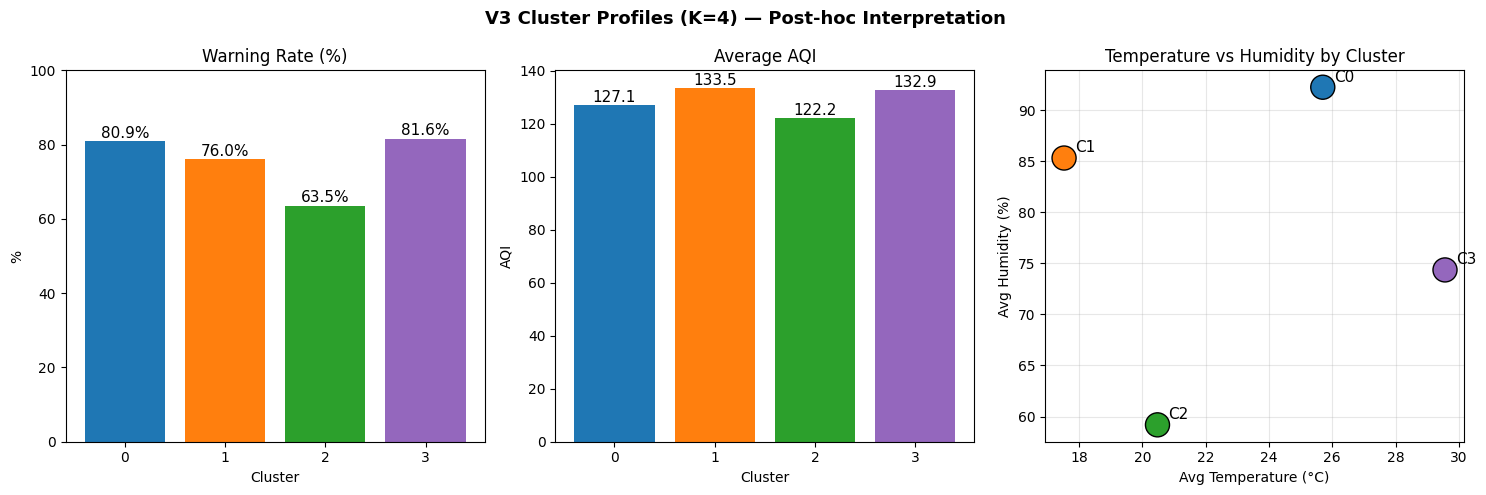

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('V3 Cluster Profiles (K=4) — Post-hoc Interpretation', fontsize=13, fontweight='bold')

clusters = profile_v3.index
colors = plt.cm.tab10(np.linspace(0, 0.4, OPTIMAL_K))

# Warning rate
axes[0].bar(clusters, profile_v3['warning_rate'], color=colors)
axes[0].set_title('Warning Rate (%)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].set_xticks(clusters)
for i, v in enumerate(profile_v3['warning_rate']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=11)

# Average AQI
axes[1].bar(clusters, profile_v3['avg_aqi'], color=colors)
axes[1].set_title('Average AQI')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(clusters)
for i, v in enumerate(profile_v3['avg_aqi']):
    axes[1].text(i, v + 1, f'{v}', ha='center', fontsize=11)

# Average Temperature vs Humidity scatter
axes[2].scatter(
    profile_v3['temperature'], profile_v3['humidity'],
    c=colors, s=300, edgecolors='black', zorder=5
)
for i, row in profile_v3.iterrows():
    axes[2].annotate(f'C{i}', (row['temperature'], row['humidity']),
                     textcoords='offset points', xytext=(8, 4), fontsize=11)
axes[2].set_title('Temperature vs Humidity by Cluster')
axes[2].set_xlabel('Avg Temperature (°C)')
axes[2].set_ylabel('Avg Humidity (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.10 Summary

In [23]:
# pca_v2 and pca_v3 were already fitted in section 3.6
summary = pd.DataFrame({
    'Metric': ['Features used', 'Optimal K', 'Inertia (loss)',
               'Silhouette score', 'PCA variance explained (PC1+PC2)'],
    'V2 — Weather Only': [
        ', '.join(FEATURES_V2), OPTIMAL_K,
        f'{km_v2.inertia_:,.1f}', f'{sil_v2:.4f}',
        f'{pca_v2.explained_variance_ratio_.sum():.2%}'
    ],
    'V3 — Weather + Time (final)': [
        ', '.join(FEATURES_V3), OPTIMAL_K,
        f'{km_v3.inertia_:,.1f}', f'{sil_v3:.4f}',
        f'{pca_v3.explained_variance_ratio_.sum():.2%}'
    ]
})

print(summary.to_string(index=False))
print()
print('V3 (K=4) is selected as the final model.')
print('It captures both seasonal (weather) and diurnal (time-of-day) patterns')
print('that are key drivers of PM2.5 pollution in Hanoi.')

                          Metric                           V2 — Weather Only                                     V3 — Weather + Time (final)
                   Features used temperature, humidity, wind_speed, pressure temperature, humidity, wind_speed, pressure, hour_sin, hour_cos
                       Optimal K                                           4                                                               4
                  Inertia (loss)                                    15,224.6                                                        22,295.4
                Silhouette score                                      0.2634                                                          0.2209
PCA variance explained (PC1+PC2)                                      75.90%                                                          65.59%

V3 (K=4) is selected as the final model.
It captures both seasonal (weather) and diurnal (time-of-day) patterns
that are key drivers of PM2.5 pollution i